In [30]:
import requests
import pandas as pd
import numpy as np
import matplotlib
from matplotlib import pyplot as plt
import nba_api
from nba_api.stats.endpoints import playercareerstats
from nba_api.stats.static import players


In [31]:
future_star = 'Cooper Flagg'

names = [future_star, 'LeBron James', 'Scottie Pippen', 
         'Jayson Tatum', 'Paul George', 'Andrei Kirilenko', 
         'Draymond Green', 'Scottie Barnes', 'Grant Hill', 
         'Franz Wagner', 'Kawhi Leonard']
id_list=[]
df_list=[]

for name in names:
    id_list.append(players.find_players_by_full_name(name)[0]['id'])
    
for id in id_list:
    df = playercareerstats.PlayerCareerStats(id, per_mode36='PerGame')
    df_list.append(df.season_totals_regular_season.get_data_frame())

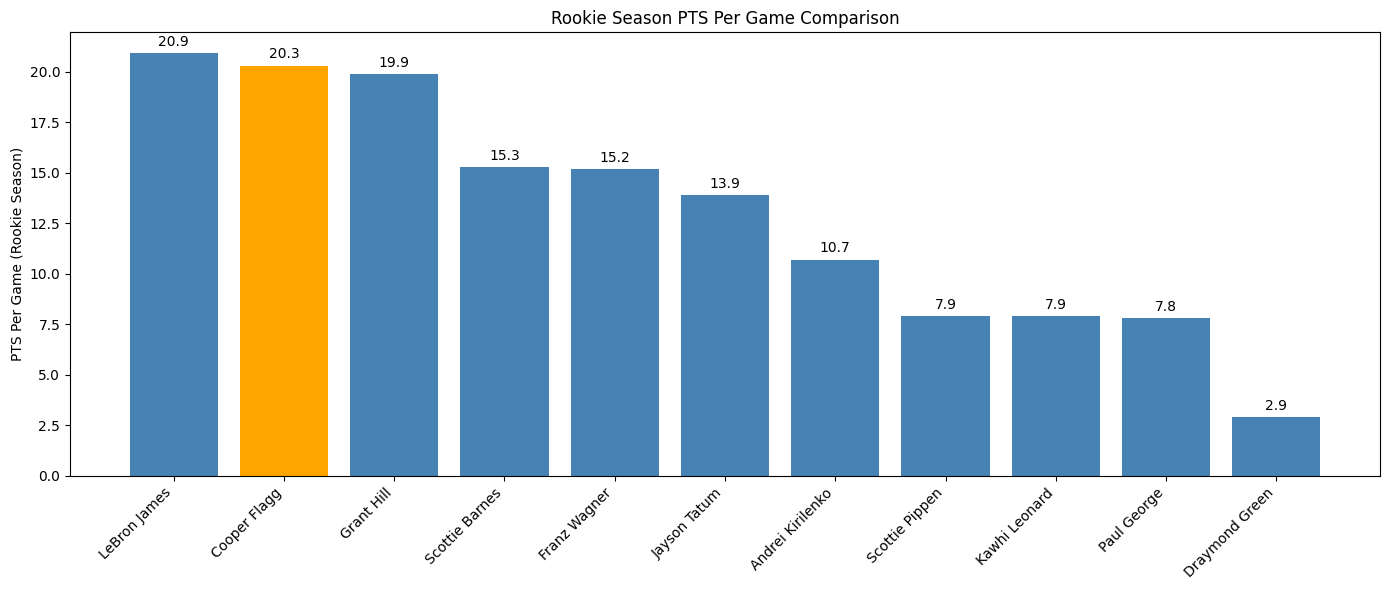

In [32]:
rookie_pts = []
for name, df in zip(names, df_list):
    rookie_pts.append((name, df.iloc[0]['PTS']))

rookie_pts.sort(key=lambda x: x[1], reverse=True)

names_list = [x[0] for x in rookie_pts]
pts_list = [x[1] for x in rookie_pts]

colors = ['orange' if name == future_star else 'steelblue' for name in names_list]

plt.figure(figsize=(14, 6))
bars = plt.bar(names_list, pts_list, color=colors)
plt.xticks(rotation=45, ha='right')
plt.ylabel('PTS Per Game (Rookie Season)')
plt.title('Rookie Season PTS Per Game Comparison')
plt.bar_label(bars, fmt='%.1f', padding=3)
plt.tight_layout()
plt.show()

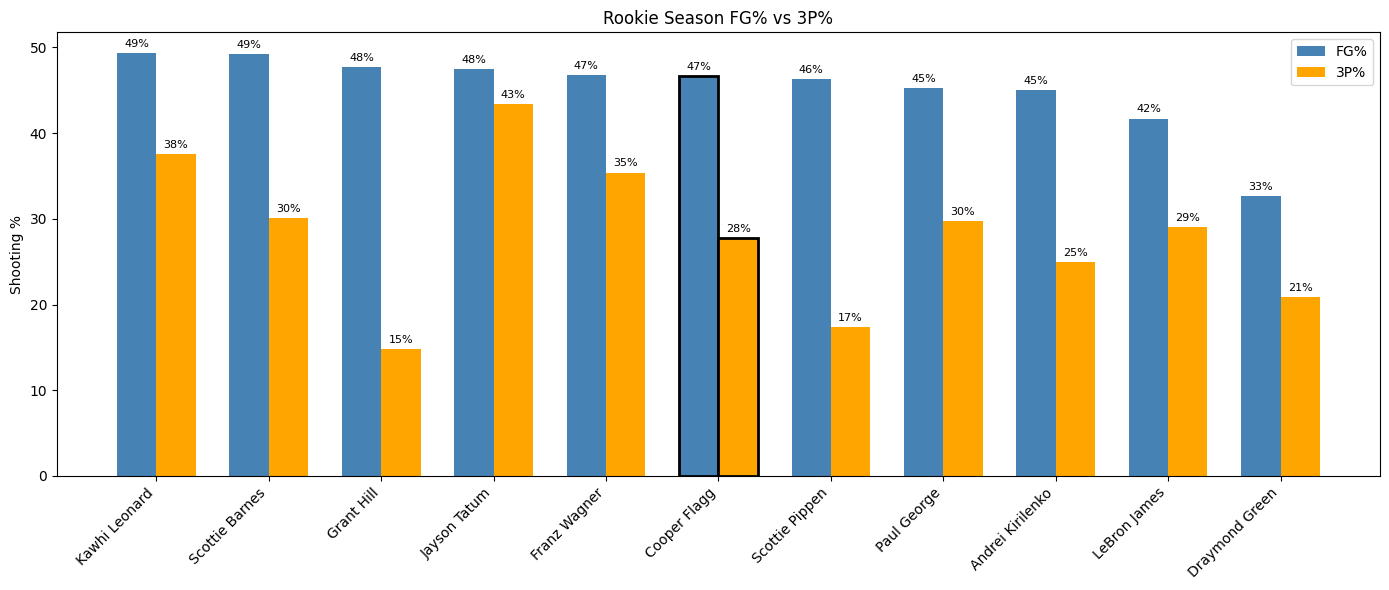

In [33]:
shooting_data = []
for name, df in zip(names, df_list):
    rookie = df.iloc[0]
    shooting_data.append((name, rookie['FG_PCT'], rookie['FG3_PCT']))

shooting_data.sort(key=lambda x: x[1], reverse=True)

names_list = [x[0] for x in shooting_data]
fg_pct = [x[1] * 100 for x in shooting_data]
fg3_pct = [x[2] * 100 for x in shooting_data]

x = np.arange(len(names_list))
width = 0.35 

edge_colors1 = ['black' if name == future_star else 'none' for name in names_list]
edge_colors2 = ['black' if name == future_star else 'none' for name in names_list]

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, fg_pct, width, label='FG%', color='steelblue', edgecolor=edge_colors1, linewidth=2)
bars2 = ax.bar(x + width/2, fg3_pct, width, label='3P%', color='orange', edgecolor=edge_colors2, linewidth=2)

ax.set_xticks(x)
ax.set_xticklabels(names_list, rotation=45, ha='right')
ax.set_ylabel('Shooting %')
ax.set_title('Rookie Season FG% vs 3P%')
ax.legend()
ax.bar_label(bars1, fmt='%.0f%%', padding=3, fontsize=8)
ax.bar_label(bars2, fmt='%.0f%%', padding=3, fontsize=8)

plt.tight_layout()
plt.show()

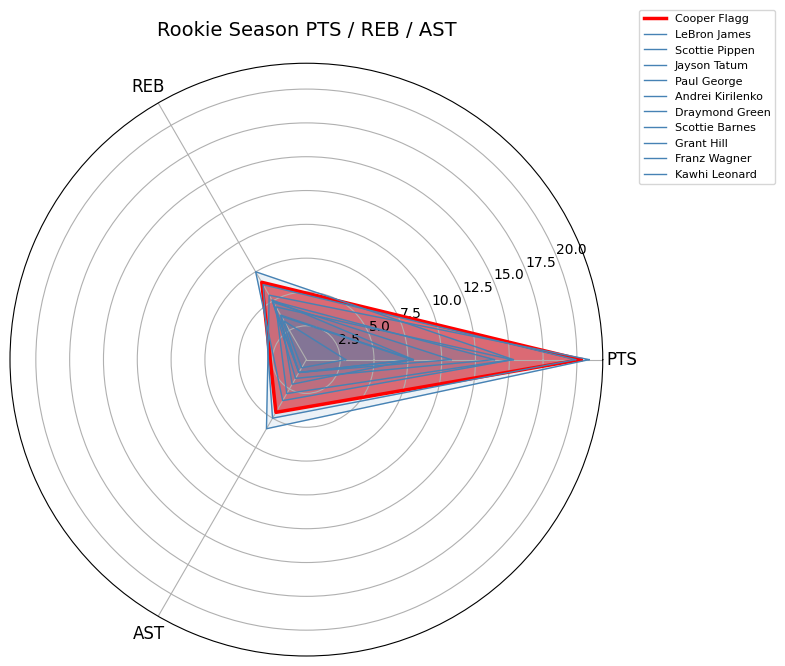

In [34]:
radar_data = []
for name, df in zip(names, df_list):
    rookie = df.iloc[0]
    radar_data.append((name, rookie['PTS'], rookie['REB'], rookie['AST']))

categories = ['PTS', 'REB', 'AST']
N = len(categories)

angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1] 

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for name, pts, reb, ast in radar_data:
    values = [pts, reb, ast]
    values += values[:1]  
    
    color = 'red' if name == future_star else 'steelblue'
    alpha = 0.6 if name == future_star else 0.1
    linewidth = 2.5 if name == future_star else 1

    ax.plot(angles, values, color=color, linewidth=linewidth, label=name)
    ax.fill(angles, values, color=color, alpha=alpha)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, fontsize=12)
ax.set_title('Rookie Season PTS / REB / AST', fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1), fontsize=8)

plt.tight_layout()
plt.show()

In [35]:
future_star_score = 0
score_list = []

for i in range(1, len(df_list)):
    if df_list[0].iloc[0]['FG_PCT'] >= df_list[i].iloc[0]['FG_PCT']:
        future_star_score += 1
        print(future_star + " has a better FG_PCT than " + names[i])
        
    if df_list[0].iloc[0]['FG3_PCT'] >= df_list[i].iloc[0]['FG3_PCT']:
        future_star_score += 1
        print(future_star + " has a better FG3_PCT than " + names[i])
        
    if df_list[0].iloc[0]['REB'] >= df_list[i].iloc[0]['REB']:
        future_star_score += 1
        print(future_star + " has more REB/game than " + names[i])
        
    if df_list[0].iloc[0]['AST'] >= df_list[i].iloc[0]['AST']:
        future_star_score += 1
        print(future_star + " has more AST/game than " + names[i])


    future_star_stock = (df_list[0].iloc[0]['STL'] + df_list[0].iloc[0]['BLK'])
    i_stock = (df_list[i].iloc[0]['STL'] + df_list[i].iloc[0]['BLK'])
               
    if future_star_stock >= i_stock:
        future_star_score += 1
        print(future_star + " has more STL+BLK/game than " + names[i])
        
    if df_list[0].iloc[0]['PTS'] >= df_list[i].iloc[0]['PTS']:
        future_star_score += 1
        print(future_star + " has more PTS/game than " + names[i])
    print(f"{future_star_score}/6")    
    print("")
    
    score_list.append(future_star_score / 6.0)
    future_star_score = 0
    
score_list

Cooper Flagg has a better FG_PCT than LeBron James
Cooper Flagg has more REB/game than LeBron James
2/6

Cooper Flagg has a better FG_PCT than Scottie Pippen
Cooper Flagg has a better FG3_PCT than Scottie Pippen
Cooper Flagg has more REB/game than Scottie Pippen
Cooper Flagg has more AST/game than Scottie Pippen
Cooper Flagg has more STL+BLK/game than Scottie Pippen
Cooper Flagg has more PTS/game than Scottie Pippen
6/6

Cooper Flagg has more REB/game than Jayson Tatum
Cooper Flagg has more AST/game than Jayson Tatum
Cooper Flagg has more STL+BLK/game than Jayson Tatum
Cooper Flagg has more PTS/game than Jayson Tatum
4/6

Cooper Flagg has a better FG_PCT than Paul George
Cooper Flagg has more REB/game than Paul George
Cooper Flagg has more AST/game than Paul George
Cooper Flagg has more STL+BLK/game than Paul George
Cooper Flagg has more PTS/game than Paul George
5/6

Cooper Flagg has a better FG_PCT than Andrei Kirilenko
Cooper Flagg has a better FG3_PCT than Andrei Kirilenko
Cooper F

[0.3333333333333333,
 1.0,
 0.6666666666666666,
 0.8333333333333334,
 0.8333333333333334,
 1.0,
 0.5,
 0.5,
 0.6666666666666666,
 0.6666666666666666]

In [36]:
future_star_total = sum(score_list)
future_star_total

7.0

In [37]:
future_star_similarity_score = future_star_total/10.0
print(future_star_similarity_score * 100)

70.0


In [38]:
#(similarity score * .70) + (base rate * .30) + 5% = end result.

base_rate = 0.52 
#52% of top 5 drafted forwards went on to become All-Stars

end_result = ((future_star_similarity_score * .70) + (base_rate * 0.30) + 0.05)
print(end_result * 100)

69.6
